In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/shopee-product-matching/sample_submission.csv
/kaggle/input/competitions/shopee-product-matching/train.csv
/kaggle/input/competitions/shopee-product-matching/test.csv


KeyboardInterrupt: 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

In [4]:
DATA_DIR = "/kaggle/input/competitions/shopee-product-matching"

train = pd.read_csv(f"{DATA_DIR}/train.csv")

print("Shape:", train.shape)
train.head()

Shape: (34250, 5)


,posting_id,image,image_phash,title,label_group
0,train_129225211,0000a68812bc7e98c42888dfb1c07da0.jpg,94974f937d4c2433,Paper Bag Victoria Secret,249114794
1,train_3386243561,00039780dfc94d01db8676fe789ecd05.jpg,af3f9460c2838f0f,"Double Tape 3M VHB 12 mm x 4,5 m ORIGINAL / DO...",2937985045
2,train_2288590299,000a190fdd715a2a36faed16e2c65df7.jpg,b94cb00ed3e50f78,Maling TTS Canned Pork Luncheon Meat 397 gr,2395904891
3,train_2406599165,00117e4fc239b1b641ff08340b429633.jpg,8514fc58eafea283,Daster Batik Lengan pendek - Motif Acak / Camp...,4093212188
4,train_3369186413,00136d1cf4edede0203f32f05f660588.jpg,a6f319f924ad708c,Nescafe \xc3\x89clair Latte 220ml,3648931069


## Using TF-IDF and Cosine Similarity based Model

In [5]:
from sklearn.model_selection import train_test_split

train_indices = []
val_indices = []

for label, group in train.groupby("label_group"):
    indices_group = group.index.tolist()

    # Groups with only one product stay entirely in training
    if len(indices_group) == 1:
        train_indices.extend(indices_group)
    else:
        # Put 20% in validation, but keep at least 1 in training
        n_val = max(1, int(len(indices_group) * 0.2))
        n_val = min(n_val, len(indices_group) - 1)

        val_group, train_group = train_test_split(
            indices_group,
            test_size=len(indices_group) - n_val,
            random_state=42
        )

        val_indices.extend(val_group)
        train_indices.extend(train_group)

train_data = train.loc[train_indices].reset_index(drop=True)
val_data = train.loc[val_indices].reset_index(drop=True)

print("Train:", train_data.shape)
print("Validation:", val_data.shape)

Train: (22676, 5)
Validation: (11574, 5)


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2
)

X_train = vectorizer.fit_transform(train_data["title"])
X_val = vectorizer.transform(val_data["title"])

print("Train TF-IDF:", X_train.shape)
print("Validation TF-IDF:", X_val.shape)

Train TF-IDF: (22676, 35908)
Validation TF-IDF: (11574, 35908)


In [7]:
from sklearn.neighbors import NearestNeighbors

knn = NearestNeighbors(
    n_neighbors=10,
    metric="cosine",
    n_jobs=-1
)

knn.fit(X_train)

distances, indices = knn.kneighbors(X_val)

similarities = 1 - distances

In [8]:
same_group = 0
total = 0

same_sim = []
diff_sim = []

for i in range(len(val_data)):
    for j, sim in zip(indices[i], similarities[i]):

        if val_data.iloc[i]["label_group"] == train_data.iloc[j]["label_group"]:
            same_group += 1
            same_sim.append(sim)
        else:
            diff_sim.append(sim)

        total += 1

print("Same-group percentage:", same_group / total * 100)

print("Average similarity - same group:",
      np.mean(same_sim))

print("Average similarity - different group:",
      np.mean(diff_sim))

Same-group percentage: 17.673233108691896
Average similarity - same group: 0.6280873998515815
Average similarity - different group: 0.35758840340305187


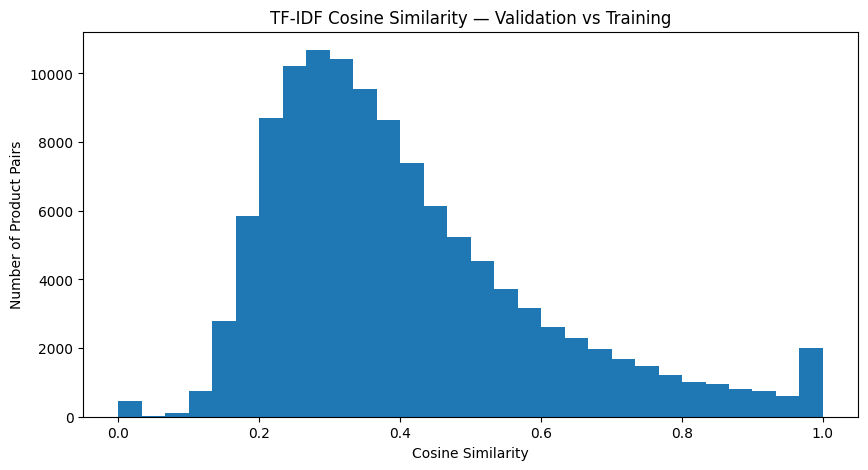

In [10]:
plt.figure(figsize=(10, 5))

plt.hist(similarities.flatten(), bins=30)

plt.xlabel("Cosine Similarity")
plt.ylabel("Number of Product Pairs")
plt.title("TF-IDF Cosine Similarity — Validation vs Training")

plt.show()

Spike at cosine similarity of 1 shows many products have same titles 

In [17]:
f1_scores = []
f1_scores_threshold = []

for threshold in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    for i in range(len(val_data)):
    
        true_matches = set(
            train_data[
                train_data["label_group"] == val_data.iloc[i]["label_group"]
            ]["posting_id"]
        )
    
        # Our predicted posting IDs
        predicted_matches = {
            train_data.iloc[j]["posting_id"]
            for j, sim in zip(indices[i], similarities[i])
            if sim >= threshold
        }
    
        intersection = len(true_matches & predicted_matches)
    
        if len(predicted_matches) == 0:
            f1 = 0.0
        else:
            f1 = (
                2 * intersection
                / (len(true_matches) + len(predicted_matches))
            )
    
        f1_scores.append(f1)
    
    mean_f1 = np.mean(f1_scores)

    print(f"Mean sample-wise F1: {mean_f1:.4f}")
    f1_scores_threshold.append(mean_f1)

Mean sample-wise F1: 0.3725
Mean sample-wise F1: 0.4125
Mean sample-wise F1: 0.4294
Mean sample-wise F1: 0.4241
Mean sample-wise F1: 0.4033
Mean sample-wise F1: 0.3738


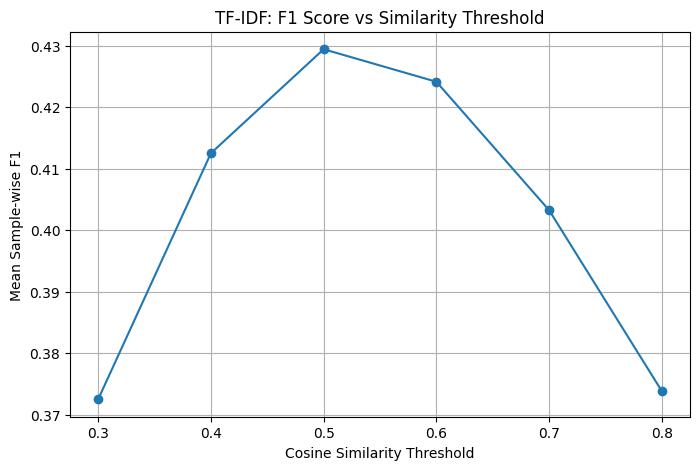

In [19]:
plt.figure(figsize=(8, 5))
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
plt.plot(thresholds, f1_scores_threshold, marker="o")

plt.xlabel("Cosine Similarity Threshold")
plt.ylabel("Mean Sample-wise F1")
plt.title("TF-IDF: F1 Score vs Similarity Threshold")
plt.grid(True)

plt.show()

Thus choose 0.5 threshold

In [20]:
threshold = 0.5

correct_matches = []
false_matches = []
missed_matches = []

for i in range(len(val_data)):
    val_title = val_data.iloc[i]["title"]
    val_group = val_data.iloc[i]["label_group"]

    for j, sim in zip(indices[i], similarities[i]):

        train_title = train_data.iloc[j]["title"]
        train_group = train_data.iloc[j]["label_group"]

        actual_match = val_group == train_group
        predicted_match = sim >= threshold

        example = {
            "validation_title": val_title,
            "training_title": train_title,
            "similarity": sim,
            "validation_group": val_group,
            "training_group": train_group
        }

        if actual_match and predicted_match:
            correct_matches.append(example)

        elif not actual_match and predicted_match:
            false_matches.append(example)

        elif actual_match and not predicted_match:
            missed_matches.append(example)

In [21]:
print("CORRECT MATCHES")
print("=" * 60)

for x in correct_matches[:5]:
    print(f"Similarity: {x['similarity']:.3f}")
    print("Validation:", x["validation_title"])
    print("Training:  ", x["training_title"])
    print()


print("\nFALSE MATCHES")
print("=" * 60)

for x in false_matches[:5]:
    print(f"Similarity: {x['similarity']:.3f}")
    print("Validation:", x["validation_title"])
    print("Training:  ", x["training_title"])
    print()


print("\nMISSED MATCHES")
print("=" * 60)

for x in missed_matches[:5]:
    print(f"Similarity: {x['similarity']:.3f}")
    print("Validation:", x["validation_title"])
    print("Training:  ", x["training_title"])
    print()

CORRECT MATCHES
Similarity: 0.523
Validation: WARNA RANDOM ACAK Sarung Celana Wadimor MURAH Celana Sarung WADIMOR
Training:   SARUNG CELANA WADIMOR DEWASA HITAM POLOS SARCEL

Similarity: 0.566
Validation: LVN COLLAGEN - ORIGINAL TERMURAH - LVN STROBERI - GARANSI UANG KEMBALI
Training:   LVN COLLAGEN / STROBERI

Similarity: 0.566
Validation: LVN COLLAGEN - ORIGINAL TERMURAH - LVN STROBERI - GARANSI UANG KEMBALI
Training:   LVN COLLAGEN / STROBERI

Similarity: 0.680
Validation: [ORIGINAL] LVN COLLAGEN / POMEGLOW COLLAGEN 1 BOX ISI 10 SACHET / GLOWING/ PEMUTIH WAJAH BADAN
Training:   GROSIR LVN COLLAGEN / COLAGEN STROBERI PEMUTIH KULIT 1 BOX ISI 10 SACHET

Similarity: 0.545
Validation: [ORIGINAL] LVN COLLAGEN / POMEGLOW COLLAGEN 1 BOX ISI 10 SACHET / GLOWING/ PEMUTIH WAJAH BADAN
Training:   LVN COLLAGEN LVN STROBERI ORIGINAL 100% 1BOX ISI 10 SACHET


FALSE MATCHES
Similarity: 0.603
Validation: WARNA RANDOM ACAK Sarung Celana Wadimor MURAH Celana Sarung WADIMOR
Training:   Sarung WADIMOR



In [22]:
from sklearn.feature_extraction.text import CountVectorizer

ngram_vectorizer = CountVectorizer(
    lowercase=True,
    binary=True,
    ngram_range=(1, 3),
    min_df=2
)

X_train_ngram = ngram_vectorizer.fit_transform(train_data["title"])
X_val_ngram = ngram_vectorizer.transform(val_data["title"])

print("Train shape:", X_train_ngram.shape)
print("Validation shape:", X_val_ngram.shape)

Train shape: (22676, 53942)
Validation shape: (11574, 53942)


In [24]:
ngram_knn = NearestNeighbors(
    n_neighbors=10,
    metric="cosine",
    n_jobs=-1
)

ngram_knn.fit(X_train_ngram)

ngram_distances, ngram_indices = ngram_knn.kneighbors(X_val_ngram)

ngram_similarities = 1 - ngram_distances

In [25]:
threshold = 0.5
ngram_f1_scores = []

for i in range(len(val_data)):

    true_matches = set(
        train_data[
            train_data["label_group"] == val_data.iloc[i]["label_group"]
        ]["posting_id"]
    )

    predicted_matches = {
        train_data.iloc[j]["posting_id"]
        for j, sim in zip(ngram_indices[i], ngram_similarities[i])
        if sim >= threshold
    }

    intersection = len(true_matches & predicted_matches)

    if len(predicted_matches) == 0:
        f1 = 0.0
    else:
        f1 = 2 * intersection / (
            len(true_matches) + len(predicted_matches)
        )

    ngram_f1_scores.append(f1)

mean_ngram_f1 = np.mean(ngram_f1_scores)

print(f"Word n-gram Mean F1: {mean_ngram_f1:.4f}")

Word n-gram Mean F1: 0.4522


In [26]:
tfidf_ngram = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 3),
    min_df=2
)

X_train_tfidf_ngram = tfidf_ngram.fit_transform(train_data["title"])
X_val_tfidf_ngram = tfidf_ngram.transform(val_data["title"])

print("Train shape:", X_train_tfidf_ngram.shape)
print("Validation shape:", X_val_tfidf_ngram.shape)

Train shape: (22676, 53942)
Validation shape: (11574, 53942)


In [27]:
tfidf_ngram_knn = NearestNeighbors(
    n_neighbors=10,
    metric="cosine",
    n_jobs=-1
)

tfidf_ngram_knn.fit(X_train_tfidf_ngram)

tfidf_ngram_distances, tfidf_ngram_indices = (
    tfidf_ngram_knn.kneighbors(X_val_tfidf_ngram)
)

tfidf_ngram_similarities = 1 - tfidf_ngram_distances

In [29]:
threshold = 0.5
tfidf_ngram_f1_scores = []

for i in range(len(val_data)):

    true_matches = set(
        train_data[
            train_data["label_group"] == val_data.iloc[i]["label_group"]
        ]["posting_id"]
    )

    predicted_matches = {
        train_data.iloc[j]["posting_id"]
        for j, sim in zip(
            tfidf_ngram_indices[i],
            tfidf_ngram_similarities[i]
        )
        if sim >= threshold
    }

    intersection = len(true_matches & predicted_matches)

    if len(predicted_matches) == 0:
        f1 = 0.0
    else:
        f1 = 2 * intersection / (
            len(true_matches) + len(predicted_matches)
        )

    tfidf_ngram_f1_scores.append(f1)

mean_tfidf_ngram_f1 = np.mean(tfidf_ngram_f1_scores)

print(f"TF-IDF word n-gram Mean F1: {mean_tfidf_ngram_f1:.4f}")

TF-IDF word n-gram Mean F1: 0.4486
